# Part 04 - Model Tuning, Interpretability & Customer Value Analysis

This notebook improves and analyses the Random Forest CLV model created in Part 03.

The model will be tuned using cross-validation, the main factors behind its predictions will be analysed, and customers will be grouped into different value segments.

## 1. Load the Required Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, RandomizedSearchCV
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

## 2. Load the Customer-Level CLV Dataset

Part 04 starts from the customer-level dataset created in Part 02.

The same dataset and target definition used in Part 03 will be used here so that the tuned model can be compared fairly with the original Random Forest.

In [2]:
file_path = "../data/processed/customer_clv_dataset.csv"

customer_data = pd.read_csv(
    file_path,
    parse_dates=[
        "first_purchase_date",
        "last_purchase_date"
    ]
)

customer_data.head()

,CustomerID,first_purchase_date,last_purchase_date,Recency,Tenure_days,Tenure_months,active_days,Frequency,Monetary,AvgOrderValue,PurchaseFrequency,ProductDiversity,Future_90d_Orders,Future_90d_Value
0,12346,2009-12-14 08:34:00,2011-01-18 10:01:00,235,635,21.2,636,12,77556.46,6463.038333,0.018868,27,0,0.00
1,12347,2010-10-31 14:20:00,2011-08-02 08:48:00,39,313,10.4,314,6,3402.39,567.065000,0.019108,107,2,1519.14
2,12348,2010-09-27 14:59:00,2011-04-05 10:47:00,158,347,11.6,348,4,1709.40,427.350000,0.011494,25,1,310.00
3,12349,2010-04-29 13:20:00,2010-10-28 08:23:00,317,498,16.6,499,3,2671.14,890.380000,0.006012,90,1,1757.55
4,12350,2011-02-02 16:01:00,2011-02-02 16:01:00,219,219,7.3,220,1,334.40,334.400000,0.004545,17,0,0.00


### 2.1 Basic Dataset Check

In [3]:
customer_data.shape

(5281, 14)

In [4]:
customer_data.dtypes

CustomerID                      int64
first_purchase_date    datetime64[ns]
last_purchase_date     datetime64[ns]
Recency                         int64
Tenure_days                     int64
Tenure_months                 float64
active_days                     int64
Frequency                       int64
Monetary                      float64
AvgOrderValue                 float64
PurchaseFrequency             float64
ProductDiversity                int64
Future_90d_Orders               int64
Future_90d_Value              float64
dtype: object

In [5]:
customer_data.isnull().sum()

CustomerID             0
first_purchase_date    0
last_purchase_date     0
Recency                0
Tenure_days            0
Tenure_months          0
active_days            0
Frequency              0
Monetary               0
AvgOrderValue          0
PurchaseFrequency      0
ProductDiversity       0
Future_90d_Orders      0
Future_90d_Value       0
dtype: int64

In [6]:
customer_data["CustomerID"].nunique()

5281

In [7]:
customer_data["Future_90d_Value"].describe()

count      5281.000000
mean        575.905666
std        4019.926054
min           0.000000
25%           0.000000
50%           0.000000
75%         434.900000
max      168469.600000
Name: Future_90d_Value, dtype: float64

## 3. Define the Model Features and Target

The same historical customer features from Part 03 will be used.

Customer ID, raw date fields, the target, and future-period information will not be used as model inputs.

In [8]:
feature_columns = [
    "Recency",
    "Tenure_days",
    "Tenure_months",
    "active_days",
    "Frequency",
    "Monetary",
    "AvgOrderValue",
    "PurchaseFrequency",
    "ProductDiversity"
]

target_column = "Future_90d_Value"

X = customer_data[feature_columns].copy()
y = customer_data[target_column].copy()

In [9]:
X.head()

,Recency,Tenure_days,Tenure_months,active_days,Frequency,Monetary,AvgOrderValue,PurchaseFrequency,ProductDiversity
0,235,635,21.2,636,12,77556.46,6463.038333,0.018868,27
1,39,313,10.4,314,6,3402.39,567.065000,0.019108,107
2,158,347,11.6,348,4,1709.40,427.350000,0.011494,25
3,317,498,16.6,499,3,2671.14,890.380000,0.006012,90
4,219,219,7.3,220,1,334.40,334.400000,0.004545,17


In [10]:
X.shape, y.shape

((5281, 9), (5281,))

In [11]:
X.columns.tolist()

['Recency',
 'Tenure_days',
 'Tenure_months',
 'active_days',
 'Frequency',
 'Monetary',
 'AvgOrderValue',
 'PurchaseFrequency',
 'ProductDiversity']

## 4. Train-Test Split

The same 80/20 customer-level split used in Part 03 will be recreated.

The test set will remain separate from cross-validation and hyperparameter tuning.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [13]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((4224, 9), (1057, 9), (4224,), (1057,))

### 4.1 Verify the Modelling Data

In [14]:
X_train.isnull().sum()

Recency              0
Tenure_days          0
Tenure_months        0
active_days          0
Frequency            0
Monetary             0
AvgOrderValue        0
PurchaseFrequency    0
ProductDiversity     0
dtype: int64

In [15]:
X_test.isnull().sum()

Recency              0
Tenure_days          0
Tenure_months        0
active_days          0
Frequency            0
Monetary             0
AvgOrderValue        0
PurchaseFrequency    0
ProductDiversity     0
dtype: int64

In [16]:
(y_train < 0).sum()

np.int64(0)

In [17]:
(y_test < 0).sum()

np.int64(0)

## 5. Original Random Forest

The original Random Forest from Part 03 will be rebuilt first.

Its performance will be used as the reference point for the tuned model.

In [18]:
original_rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

original_rf.fit(
    X_train,
    y_train
)

,n_estimators,300
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [19]:
original_rf_predictions = original_rf.predict(X_test)

In [20]:
original_rf_mae = mean_absolute_error(
    y_test,
    original_rf_predictions
)

original_rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        original_rf_predictions
    )
)

original_rf_r2 = r2_score(
    y_test,
    original_rf_predictions
)

In [21]:
print("Original Random Forest Performance")
print(f"MAE: {original_rf_mae:.2f}")
print(f"RMSE: {original_rf_rmse:.2f}")
print(f"R²: {original_rf_r2:.4f}")

Original Random Forest Performance
MAE: 592.08
RMSE: 5662.33
R²: 0.0214


### 5.1 Original Random Forest Results

In [22]:
original_rf_results = pd.DataFrame({
    "Model": ["Original Random Forest"],
    "MAE": [original_rf_mae],
    "RMSE": [original_rf_rmse],
    "R²": [original_rf_r2]
})

original_rf_results

,Model,MAE,RMSE,R²
0,Original Random Forest,592.084215,5662.329944,0.02142


## 6. Random Forest Hyperparameter Tuning

The Random Forest will be tuned using 5-fold cross-validation.

Only the training data will be used during tuning. The test set will remain untouched until the final evaluation.

In [23]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

### 6.1 Hyperparameter Search Space

In [24]:
param_grid = {
    "n_estimators": [200, 300, 500, 700],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", 0.7, 1.0]
}

### 6.2 Run Randomized Search

In [25]:
random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=param_grid,
    n_iter=20,
    scoring="neg_mean_absolute_error",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [26]:
random_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,RandomForestR...ndom_state=42)
,param_distributions,"{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,n_iter,20
,scoring,'neg_mean_absolute_error'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


### 6.3 Best Hyperparameters

In [27]:
random_search.best_params_

{'n_estimators': 300,
 'min_samples_split': 5,
 'min_samples_leaf': 4,
 'max_features': 1.0,
 'max_depth': 10}

In [28]:
random_search.best_score_

np.float64(-447.2568399180851)

In [29]:
best_cv_mae = -random_search.best_score_

print(f"Best Cross-Validation MAE: {best_cv_mae:.2f}")

Best Cross-Validation MAE: 447.26


In [30]:
tuned_rf = random_search.best_estimator_
tuned_rf

,n_estimators,300
,criterion,'squared_error'
,max_depth,10
,min_samples_split,5
,min_samples_leaf,4
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 7. Tuned Random Forest Evaluation

The tuned Random Forest will now be evaluated on the untouched test set.

Its performance will be compared with the original Random Forest to determine whether hyperparameter tuning improved the model.

In [31]:
tuned_rf_predictions = tuned_rf.predict(X_test)

In [32]:
tuned_rf_mae = mean_absolute_error(
    y_test,
    tuned_rf_predictions
)

tuned_rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tuned_rf_predictions
    )
)

tuned_rf_r2 = r2_score(
    y_test,
    tuned_rf_predictions
)

In [33]:
print("Tuned Random Forest Performance")
print(f"MAE: {tuned_rf_mae:.2f}")
print(f"RMSE: {tuned_rf_rmse:.2f}")
print(f"R²: {tuned_rf_r2:.4f}")

Tuned Random Forest Performance
MAE: 576.78
RMSE: 5622.81
R²: 0.0350


### 7.1 Original vs Tuned Random Forest

In [34]:
rf_comparison = pd.DataFrame({
    "Model": [
        "Original Random Forest",
        "Tuned Random Forest"
    ],
    "MAE": [
        original_rf_mae,
        tuned_rf_mae
    ],
    "RMSE": [
        original_rf_rmse,
        tuned_rf_rmse
    ],
    "R²": [
        original_rf_r2,
        tuned_rf_r2
    ]
})

rf_comparison.round(2)

,Model,MAE,RMSE,R²
0,Original Random Forest,592.08,5662.33,0.02
1,Tuned Random Forest,576.78,5622.81,0.04


### 7.2 Improvement After Tuning

In [35]:
mae_improvement = (
    (original_rf_mae - tuned_rf_mae)
    / original_rf_mae
) * 100

rmse_improvement = (
    (original_rf_rmse - tuned_rf_rmse)
    / original_rf_rmse
) * 100

r2_improvement = (
    tuned_rf_r2 - original_rf_r2
)

print(f"MAE improvement: {mae_improvement:.2f}%")
print(f"RMSE improvement: {rmse_improvement:.2f}%")
print(f"R² change: {r2_improvement:.4f}")

MAE improvement: 2.59%
RMSE improvement: 0.70%
R² change: 0.0136


## 8. Tuned Random Forest Feature Importance

Feature importance is used to understand which historical customer features contributed most to the tuned Random Forest predictions.

In [36]:
tuned_feature_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": tuned_rf.feature_importances_
})

tuned_feature_importance = tuned_feature_importance.sort_values(
    "Importance",
    ascending=False
)

tuned_feature_importance

,Feature,Importance
5,Monetary,0.926632
0,Recency,0.016232
8,ProductDiversity,0.016051
4,Frequency,0.012278
6,AvgOrderValue,0.009403
7,PurchaseFrequency,0.008881
1,Tenure_days,0.004351
3,active_days,0.003481
2,Tenure_months,0.002691


In [37]:
tuned_feature_importance.round(4)

,Feature,Importance
5,Monetary,0.9266
0,Recency,0.0162
8,ProductDiversity,0.0161
4,Frequency,0.0123
6,AvgOrderValue,0.0094
7,PurchaseFrequency,0.0089
1,Tenure_days,0.0044
3,active_days,0.0035
2,Tenure_months,0.0027


### 8.1 Feature Importance Plot

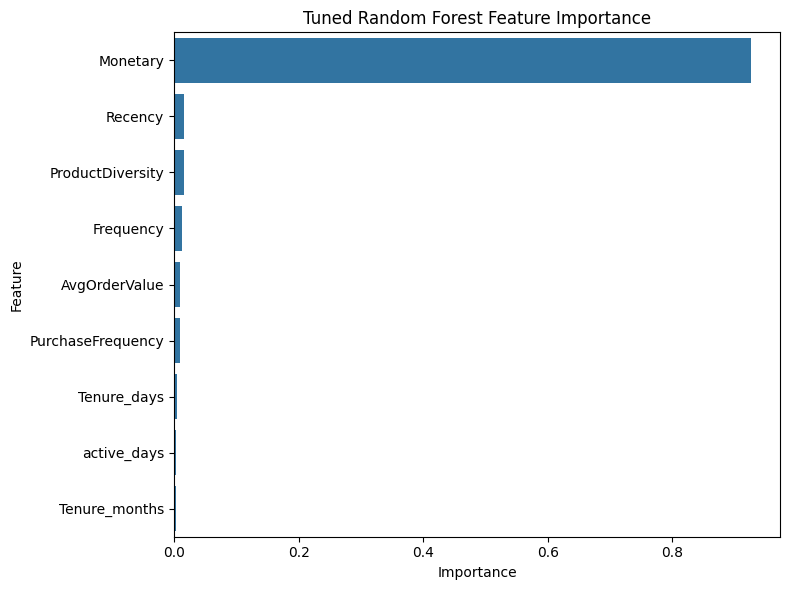

In [38]:
plt.figure(figsize=(8, 6))

sns.barplot(
    data=tuned_feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Tuned Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig(
    "../images/11_tuned_rf_feature_importance.png"
)

plt.show()

## 9. Permutation Importance

Permutation importance measures how much the model's performance changes when the values of one feature are randomly shuffled.

A larger decrease in model performance indicates that the feature was more important to the model's predictions.

In [39]:
permutation_result = permutation_importance(
    tuned_rf,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

In [40]:
permutation_importance_df = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": permutation_result.importances_mean
})

permutation_importance_df = permutation_importance_df.sort_values(
    "Importance",
    ascending=False
)

permutation_importance_df

,Feature,Importance
5,Monetary,300.885479
0,Recency,31.145902
7,PurchaseFrequency,19.229319
8,ProductDiversity,13.780073
6,AvgOrderValue,9.761990
3,active_days,6.885793
1,Tenure_days,6.245782
2,Tenure_months,5.257424
4,Frequency,0.606167


In [41]:
permutation_importance_df.round(4)

,Feature,Importance
5,Monetary,300.8855
0,Recency,31.1459
7,PurchaseFrequency,19.2293
8,ProductDiversity,13.7801
6,AvgOrderValue,9.7620
3,active_days,6.8858
1,Tenure_days,6.2458
2,Tenure_months,5.2574
4,Frequency,0.6062


### 9.1 Permutation Importance Plot

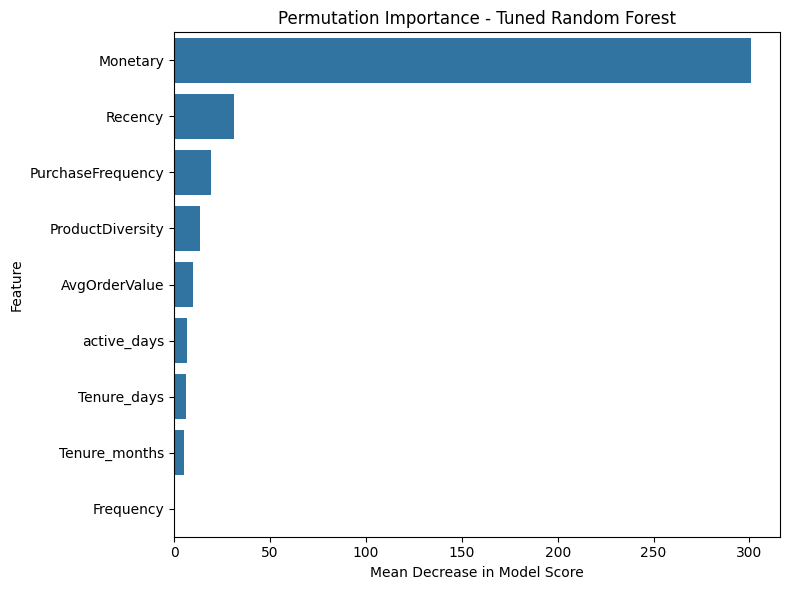

In [42]:
plt.figure(figsize=(8, 6))

sns.barplot(
    data=permutation_importance_df,
    x="Importance",
    y="Feature"
)

plt.title("Permutation Importance - Tuned Random Forest")
plt.xlabel("Mean Decrease in Model Score")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig(
    "../images/12_permutation_importance.png"
)

plt.show()

## 10. Partial Dependence Analysis

Partial dependence is used to examine how the model's predicted customer value changes as an individual feature changes.

The analysis focuses on the most important features identified by permutation importance.

### 10.1 Prepare Data for Partial Dependence

In [43]:
X_test_pdp = X_test.copy()

for column in feature_columns:
    X_test_pdp[column] = X_test_pdp[column].astype(float)

### 10.2 Monetary and Predicted CLV

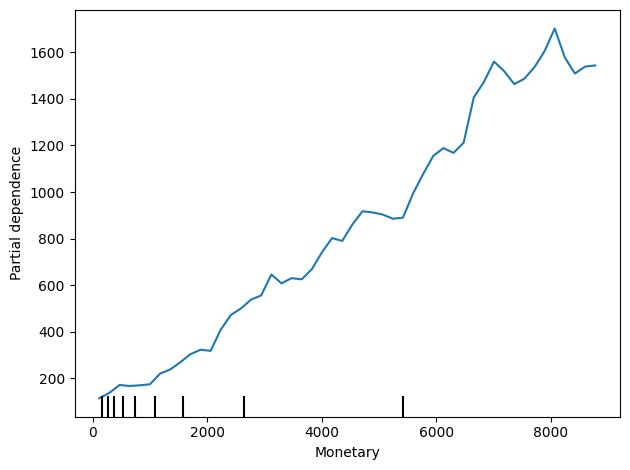

In [44]:
PartialDependenceDisplay.from_estimator(
    tuned_rf,
    X_test_pdp,
    ["Monetary"],
    grid_resolution=50
)

plt.tight_layout()

plt.savefig(
    "../images/13_partial_dependence_monetary.png"
)

plt.show()

### 10.3 Recency and Predicted CLV

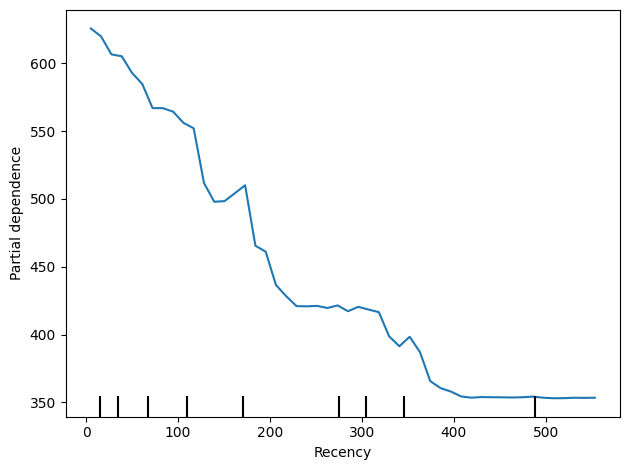

In [45]:
PartialDependenceDisplay.from_estimator(
    tuned_rf,
    X_test_pdp,
    ["Recency"],
    grid_resolution=50
)

plt.tight_layout()

plt.savefig(
    "../images/14_partial_dependence_recency.png"
)

plt.show()

### 10.4 Purchase Frequency and Predicted CLV

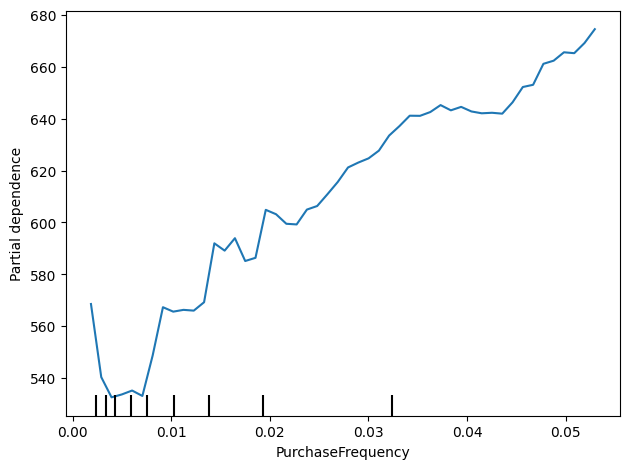

In [46]:
PartialDependenceDisplay.from_estimator(
    tuned_rf,
    X_test_pdp,
    ["PurchaseFrequency"],
    grid_resolution=50
)

plt.tight_layout()

plt.savefig(
    "../images/15_partial_dependence_purchase_frequency.png"
)

plt.show()

## 11. Predict Customer CLV

The tuned Random Forest will be used to estimate the future 90-day customer value for every customer in the dataset.

In [47]:
all_customer_predictions = tuned_rf.predict(X)

In [48]:
customer_value = customer_data[
    ["CustomerID", "Future_90d_Value"]
].copy()

customer_value["Predicted_90d_Value"] = all_customer_predictions

In [49]:
customer_value.head()

,CustomerID,Future_90d_Value,Predicted_90d_Value
0,12346,0.00,4265.083051
1,12347,1519.14,964.801316
2,12348,310.00,383.319711
3,12349,1757.55,751.823231
4,12350,0.00,91.713395


### 11.1 Prediction Check

In [50]:
customer_value["Predicted_90d_Value"].describe()

count     5281.000000
mean       532.562361
std       2475.111878
min         10.204219
25%         87.144261
50%        173.749892
75%        421.433352
max      60701.422302
Name: Predicted_90d_Value, dtype: float64

In [51]:
(customer_value["Predicted_90d_Value"] < 0).sum()

np.int64(0)

In [52]:
customer_value.shape

(5281, 3)

### 11.2 Highest Predicted Customer Value

In [53]:
top_customers = customer_value.sort_values(
    "Predicted_90d_Value",
    ascending=False
)

top_customers.head(10)

,CustomerID,Future_90d_Value,Predicted_90d_Value
2038,14646,101903.40,60701.422302
5113,18102,124206.55,60509.507041
1591,14156,18521.29,59831.429427
2275,14911,61807.38,59801.661336
1180,13694,19127.98,57299.347953
4586,17511,31686.63,56443.283568
4538,17450,108089.25,55871.730533
65,12415,22826.65,36993.942796
3853,16684,32770.06,35597.324140
2409,15061,17959.14,22552.887205


## 12. Customer Value Segmentation

Customers will be grouped into four value segments based on their predicted future 90-day customer value.

The segments are designed to help prioritize marketing and retention efforts.

In [54]:
customer_value["Value_Segment"] = pd.qcut(
    customer_value["Predicted_90d_Value"],
    q=[0, 0.50, 0.80, 0.95, 1.00],
    labels=[
        "Low",
        "Medium",
        "High",
        "VIP"
    ]
)

customer_value.head()

,CustomerID,Future_90d_Value,Predicted_90d_Value,Value_Segment
0,12346,0.00,4265.083051,VIP
1,12347,1519.14,964.801316,High
2,12348,310.00,383.319711,Medium
3,12349,1757.55,751.823231,High
4,12350,0.00,91.713395,Low


### 12.1 Segment Size

In [55]:
segment_counts = (
    customer_value["Value_Segment"]
    .value_counts()
    .sort_index()
)

segment_counts

Value_Segment
Low       2641
Medium    1584
High       792
VIP        264
Name: count, dtype: int64

In [56]:
segment_percentage = (
    customer_value["Value_Segment"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

segment_percentage.round(2)

Value_Segment
Low       50.01
Medium    29.99
High      15.00
VIP        5.00
Name: proportion, dtype: float64

### 12.2 Value by Customer Segment

In [57]:
segment_summary = (
    customer_value
    .groupby("Value_Segment", observed=True)
    .agg(
        Customers=("CustomerID", "count"),
        Total_Predicted_Value=("Predicted_90d_Value", "sum"),
        Average_Predicted_Value=("Predicted_90d_Value", "mean"),
        Median_Predicted_Value=("Predicted_90d_Value", "median")
    )
    .reset_index()
)

segment_summary

,Value_Segment,Customers,Total_Predicted_Value,Average_Predicted_Value,Median_Predicted_Value
0,Low,2641,2.201999e+05,83.377486,87.144261
1,Medium,1584,4.822518e+05,304.451876,285.078211
2,High,792,6.948756e+05,877.368166,800.012688
3,VIP,264,1.415135e+06,5360.358056,2408.621342


In [58]:
segment_summary["Value_Share_%"] = (
    segment_summary["Total_Predicted_Value"]
    / segment_summary["Total_Predicted_Value"].sum()
) * 100

segment_summary.round(2)

,Value_Segment,Customers,Total_Predicted_Value,Average_Predicted_Value,Median_Predicted_Value,Value_Share_%
0,Low,2641,220199.94,83.38,87.14,7.83
1,Medium,1584,482251.77,304.45,285.08,17.15
2,High,792,694875.59,877.37,800.01,24.71
3,VIP,264,1415134.53,5360.36,2408.62,50.32


In [59]:
segment_order = [
    "Low",
    "Medium",
    "High",
    "VIP"
]

segment_summary["Value_Segment"] = pd.Categorical(
    segment_summary["Value_Segment"],
    categories=segment_order,
    ordered=True
)

segment_summary = segment_summary.sort_values(
    "Value_Segment"
)

segment_summary.round(2)

,Value_Segment,Customers,Total_Predicted_Value,Average_Predicted_Value,Median_Predicted_Value,Value_Share_%
0,Low,2641,220199.94,83.38,87.14,7.83
1,Medium,1584,482251.77,304.45,285.08,17.15
2,High,792,694875.59,877.37,800.01,24.71
3,VIP,264,1415134.53,5360.36,2408.62,50.32


### 12.3 Customer Value Segment Distribution

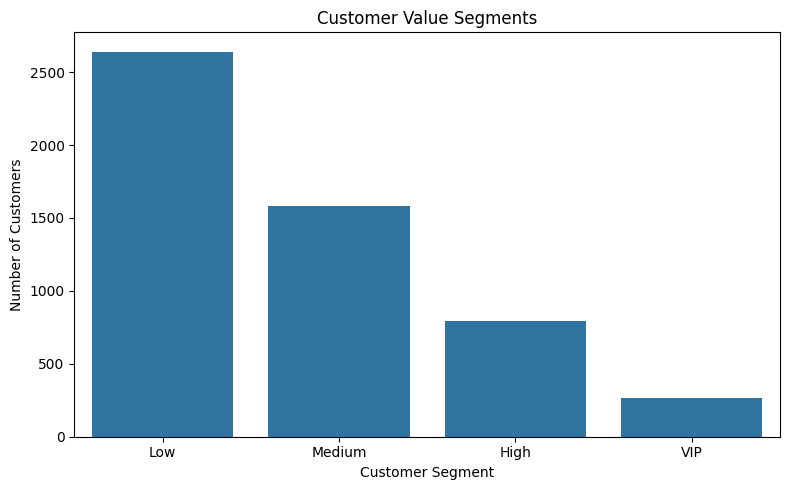

In [60]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=customer_value,
    x="Value_Segment",
    order=segment_order
)

plt.title("Customer Value Segments")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig(
    "../images/16_customer_value_segments.png"
)

plt.show()

### 12.4 Predicted CLV by Customer Segment

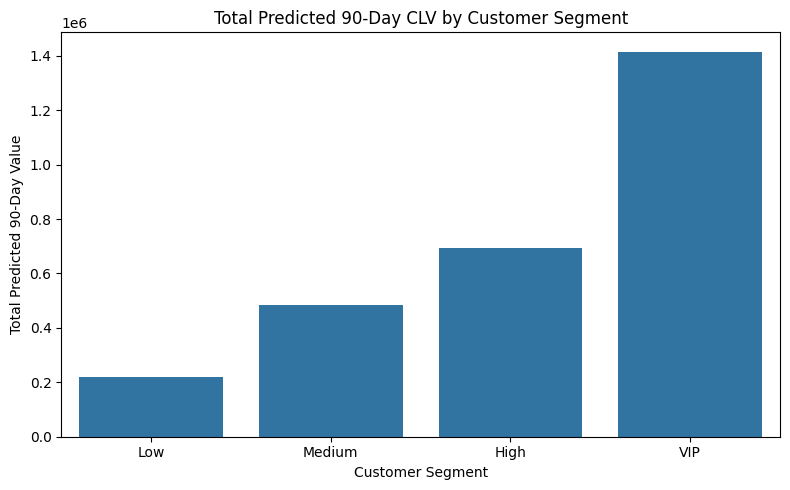

In [61]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=segment_summary,
    x="Value_Segment",
    y="Total_Predicted_Value",
    order=segment_order
)

plt.title("Total Predicted 90-Day CLV by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Predicted 90-Day Value")

plt.tight_layout()

plt.savefig(
    "../images/17_predicted_clv_by_segment.png"
)

plt.show()

## 13. Customer Value Analysis

The predicted customer value segments will be analysed further to understand how customer behaviour and actual future value differ between the segments.

### 13.1 Actual vs Predicted Value by Segment

In [62]:
segment_actual_summary = (
    customer_value
    .groupby("Value_Segment", observed=True)
    .agg(
        Customers=("CustomerID", "count"),
        Total_Actual_Value=("Future_90d_Value", "sum"),
        Average_Actual_Value=("Future_90d_Value", "mean"),
        Median_Actual_Value=("Future_90d_Value", "median"),
        Total_Predicted_Value=("Predicted_90d_Value", "sum"),
        Average_Predicted_Value=("Predicted_90d_Value", "mean")
    )
    .reset_index()
)

segment_actual_summary

,Value_Segment,Customers,Total_Actual_Value,Average_Actual_Value,Median_Actual_Value,Total_Predicted_Value,Average_Predicted_Value
0,Low,2641,345074.480,130.660538,0.000,2.201999e+05,83.377486
1,Medium,1584,514602.842,324.875532,115.895,4.822518e+05,304.451876
2,High,792,682507.000,861.751263,757.045,6.948756e+05,877.368166
3,VIP,264,1499173.500,5678.687500,2566.040,1.415135e+06,5360.358056


In [63]:
segment_actual_summary.round(2)

,Value_Segment,Customers,Total_Actual_Value,Average_Actual_Value,Median_Actual_Value,Total_Predicted_Value,Average_Predicted_Value
0,Low,2641,345074.48,130.66,0.00,220199.94,83.38
1,Medium,1584,514602.84,324.88,115.90,482251.77,304.45
2,High,792,682507.00,861.75,757.04,694875.59,877.37
3,VIP,264,1499173.50,5678.69,2566.04,1415134.53,5360.36


In [64]:
segment_actual_summary["Actual_Value_Share_%"] = (
    segment_actual_summary["Total_Actual_Value"]
    / segment_actual_summary["Total_Actual_Value"].sum()
) * 100

segment_actual_summary.round(2)

,Value_Segment,Customers,Total_Actual_Value,Average_Actual_Value,Median_Actual_Value,Total_Predicted_Value,Average_Predicted_Value,Actual_Value_Share_%
0,Low,2641,345074.48,130.66,0.00,220199.94,83.38,11.35
1,Medium,1584,514602.84,324.88,115.90,482251.77,304.45,16.92
2,High,792,682507.00,861.75,757.04,694875.59,877.37,22.44
3,VIP,264,1499173.50,5678.69,2566.04,1415134.53,5360.36,49.29


### 13.2 Customer Behaviour by Value Segment

In [65]:
segment_behavior = customer_data[
    [
        "CustomerID",
        "Recency",
        "Frequency",
        "Monetary",
        "AvgOrderValue",
        "PurchaseFrequency",
        "ProductDiversity",
        "Tenure_days"
    ]
].copy()

segment_behavior = segment_behavior.merge(
    customer_value[
        [
            "CustomerID",
            "Value_Segment"
        ]
    ],
    on="CustomerID",
    how="left"
)

In [66]:
segment_behavior_summary = (
    segment_behavior
    .groupby("Value_Segment", observed=True)
    .agg(
        Recency=("Recency", "mean"),
        Frequency=("Frequency", "mean"),
        Monetary=("Monetary", "mean"),
        AvgOrderValue=("AvgOrderValue", "mean"),
        PurchaseFrequency=("PurchaseFrequency", "mean"),
        ProductDiversity=("ProductDiversity", "mean"),
        Tenure_days=("Tenure_days", "mean")
    )
    .reset_index()
)

segment_behavior_summary.round(2)

,Value_Segment,Recency,Frequency,Monetary,AvgOrderValue,PurchaseFrequency,ProductDiversity,Tenure_days
0,Low,318.68,2.06,461.26,240.70,0.01,29.96,427.84
1,Medium,122.72,4.79,1471.99,387.27,0.02,75.86,390.84
2,High,60.33,10.74,4422.16,541.19,0.03,158.27,479.29
3,VIP,41.14,33.42,26054.47,1032.19,0.06,257.77,574.12


### 13.3 Historical Monetary by Value Segment

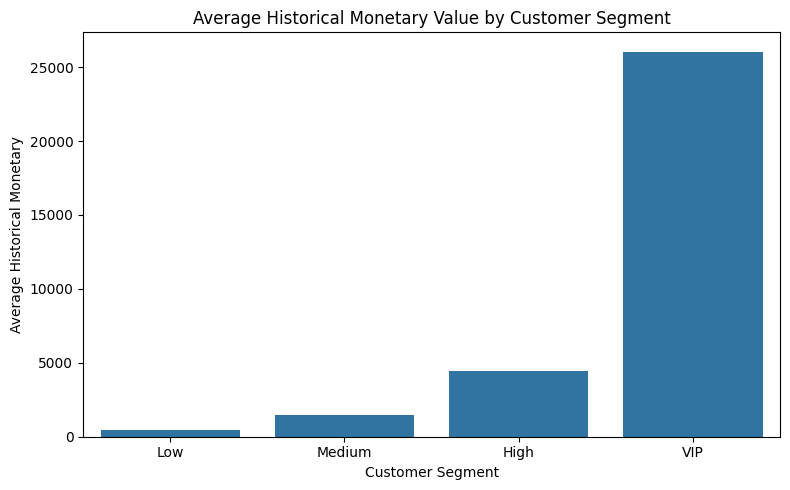

In [67]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=segment_behavior_summary,
    x="Value_Segment",
    y="Monetary",
    order=segment_order
)

plt.title("Average Historical Monetary Value by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Historical Monetary")

plt.tight_layout()

plt.savefig(
    "../images/18_historical_monetary_by_segment.png"
)

plt.show()

### 13.4 Actual vs Predicted CLV by Segment

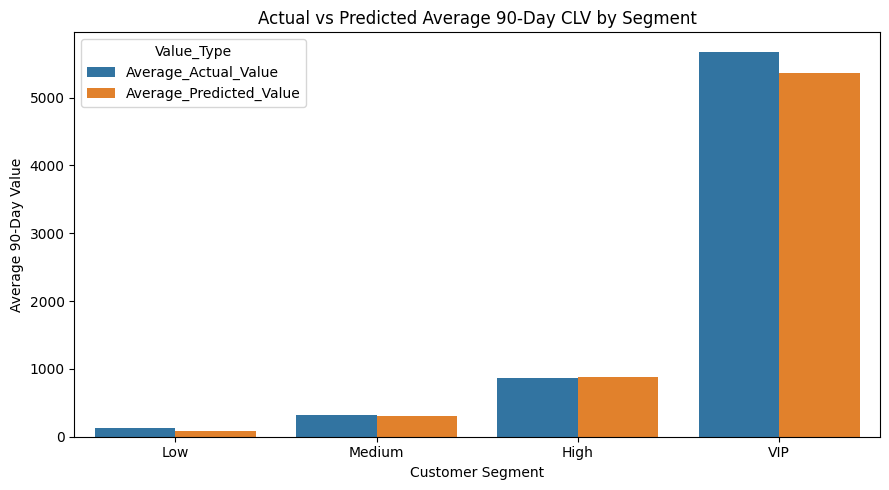

In [68]:
comparison_plot_data = segment_actual_summary[
    [
        "Value_Segment",
        "Average_Actual_Value",
        "Average_Predicted_Value"
    ]
].melt(
    id_vars="Value_Segment",
    var_name="Value_Type",
    value_name="Value"
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=comparison_plot_data,
    x="Value_Segment",
    y="Value",
    hue="Value_Type",
    order=segment_order
)

plt.title("Actual vs Predicted Average 90-Day CLV by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average 90-Day Value")

plt.tight_layout()

plt.savefig(
    "../images/19_actual_vs_predicted_clv_by_segment.png"
)

plt.show()

## 14. Final Customer Value Dataset

The final customer-level table combines the historical future value, model prediction, and customer value segment.

In [69]:
final_customer_value = customer_value[
    [
        "CustomerID",
        "Future_90d_Value",
        "Predicted_90d_Value",
        "Value_Segment"
    ]
].copy()

final_customer_value.head()

,CustomerID,Future_90d_Value,Predicted_90d_Value,Value_Segment
0,12346,0.00,4265.083051,VIP
1,12347,1519.14,964.801316,High
2,12348,310.00,383.319711,Medium
3,12349,1757.55,751.823231,High
4,12350,0.00,91.713395,Low


In [70]:
final_customer_value.shape

(5281, 4)

In [71]:
final_customer_value.isnull().sum()

CustomerID             0
Future_90d_Value       0
Predicted_90d_Value    0
Value_Segment          0
dtype: int64

In [72]:
final_customer_value["Value_Segment"].value_counts().sort_index()

Value_Segment
Low       2641
Medium    1584
High       792
VIP        264
Name: count, dtype: int64

### 14.1 Save Customer Value Scores

In [73]:
output_path = "../data/processed/customer_clv_predictions.csv"

final_customer_value.to_csv(
    output_path,
    index=False
)

print(f"Saved: {output_path}")

Saved: ../data/processed/customer_clv_predictions.csv


### 14.2 Final Segment Summary

In [74]:
final_segment_summary = segment_actual_summary[
    [
        "Value_Segment",
        "Customers",
        "Total_Actual_Value",
        "Average_Actual_Value",
        "Total_Predicted_Value",
        "Average_Predicted_Value",
        "Actual_Value_Share_%"
    ]
].copy()

final_segment_summary.round(2)

,Value_Segment,Customers,Total_Actual_Value,Average_Actual_Value,Total_Predicted_Value,Average_Predicted_Value,Actual_Value_Share_%
0,Low,2641,345074.48,130.66,220199.94,83.38,11.35
1,Medium,1584,514602.84,324.88,482251.77,304.45,16.92
2,High,792,682507.00,861.75,694875.59,877.37,22.44
3,VIP,264,1499173.50,5678.69,1415134.53,5360.36,49.29


## 15. Final Findings

The tuned Random Forest performed better than the original Random Forest on the test set.

The tuning reduced MAE from 592.08 to 576.78, reduced RMSE from 5662.33 to 5622.81, and increased R² from 0.0214 to 0.0350.

The model interpretation showed that `Monetary` was the strongest predictor of future customer value. `Recency` and purchase behaviour were also useful signals.

The partial dependence analysis showed that higher historical monetary value and higher purchase frequency were generally associated with higher predicted CLV, while higher recency was associated with lower predicted CLV.

Customer segmentation showed a strong concentration of value. The top 5% of customers were classified as VIP and represented 50.32% of total predicted future value and 49.29% of the actual future value observed in the historical evaluation period.

The VIP segment also showed much stronger historical customer behaviour, including higher monetary value, more frequent purchases, higher average order value, greater product diversity, and more recent purchases.

### 15.1 Model Performance Summary

| Model | MAE | RMSE | R² |
|---|---:|---:|---:|
| Original Random Forest | 592.08 | 5662.33 | 0.0214 |
| Tuned Random Forest | 576.78 | 5622.81 | 0.0350 |

The tuned Random Forest was selected as the final model.

The improvement was modest but consistent across all three metrics.

### 15.2 Main Factors Influencing Predicted CLV

The tuned Random Forest identified `Monetary` as the dominant feature.

The built-in feature importance and permutation importance both ranked `Monetary` as the most important predictor.

Partial dependence analysis showed:

- Higher `Monetary` was generally associated with higher predicted CLV.
- Higher `Recency` was generally associated with lower predicted CLV.
- Higher `PurchaseFrequency` was generally associated with higher predicted CLV.

These relationships describe model behaviour and should not be interpreted as causal relationships.

### 15.3 Customer Value Segments

Customers were grouped using their predicted future 90-day value:

| Segment | Customers | Customer Share | Predicted Value Share | Actual Value Share |
|---|---:|---:|---:|---:|
| Low | 2,641 | 50.01% | 7.83% | 11.35% |
| Medium | 1,584 | 29.99% | 17.15% | 16.92% |
| High | 792 | 15.00% | 24.71% | 22.44% |
| VIP | 264 | 5.00% | 50.32% | 49.29% |

The VIP segment contains only 5% of customers but accounts for approximately half of both predicted and actual future customer value.

### 15.4 Business Recommendations

#### 1. Protect VIP customers

VIP customers represent a very large share of future customer value, so retention efforts should prioritize this group.

Personalized offers, loyalty rewards, early access to products, and proactive retention campaigns could be focused on these customers.

#### 2. Move High-value customers toward VIP

High-value customers already show strong purchasing behaviour but have not reached the VIP segment.

Targeted cross-sell, upsell, and loyalty campaigns could be used to increase purchase frequency and average order value.

#### 3. Reactivate customers with high recency

Higher recency was associated with lower predicted CLV.

Customers who have not purchased for a long time should be considered for reactivation campaigns before they become permanently inactive.

#### 4. Use lower-cost campaigns for Low-value customers

The Low segment contains half of the customer base but contributes only 7.83% of predicted future value.

Automated or lower-cost marketing approaches may be more appropriate for this group than expensive one-to-one campaigns.

### 15.5 Model Limitation

The tuned Random Forest improved on the original model, but overall predictive performance remains limited.

The final test-set R² was 0.0350, meaning the model explains only a small portion of the variation in future customer value.

The future CLV target is highly skewed, with many customers having zero future value and a smaller number of customers generating very large values.

The model should therefore be used as a customer prioritisation tool rather than as an exact prediction of future revenue for every individual customer.

### Part 04 Complete

The tuned Random Forest provides a practical way to prioritise customers based on predicted future value.

The strongest opportunity is the small VIP group, which represents a disproportionately large share of future customer value.